In [1]:
import pandas as pd

df1 = pd.read_csv("data (1).csv")
print(df1.columns.tolist())
print(df1.head())

df2 = pd.read_csv("SP 500 ESG Risk Ratings.csv")
print(df2.columns.tolist())
print(df2.head())

['ticker', 'name', 'currency', 'exchange', 'industry', 'logo', 'weburl', 'environment_grade', 'environment_level', 'social_grade', 'social_level', 'governance_grade', 'governance_level', 'environment_score', 'social_score', 'governance_score', 'total_score', 'last_processing_date', 'total_grade', 'total_level', 'cik']
  ticker                           name currency  \
0    dis                 Walt Disney Co      USD   
1     gm              General Motors Co      USD   
2    gww                WW Grainger Inc      USD   
3    mhk          Mohawk Industries Inc      USD   
4    lyv  Live Nation Entertainment Inc      USD   

                        exchange                            industry  \
0  NEW YORK STOCK EXCHANGE, INC.                               Media   
1  NEW YORK STOCK EXCHANGE, INC.                         Automobiles   
2  NEW YORK STOCK EXCHANGE, INC.  Trading Companies and Distributors   
3  NEW YORK STOCK EXCHANGE, INC.                   Consumer products   
4  NEW 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import shap

C:\Users\HP\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 6.4 MB/s eta 0:00:00


In [2]:
df = pd.read_csv(
    "SP 500 ESG Risk Ratings.csv"
)

df.head()

,Symbol,Name,Address,Sector,Industry,Full Time Employees,Description,Total ESG Risk score,Environment Risk Score,Governance Risk Score,Social Risk Score,Controversy Level,Controversy Score,ESG Risk Percentile,ESG Risk Level
0,ENPH,"Enphase Energy, Inc.","47281 Bayside Parkway\nFremont, CA 94538\nUnit...",Technology,Solar,"3,157","Enphase Energy, Inc., together with its subsid...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EMN,Eastman Chemical Company,"200 South Wilcox Drive\nKingsport, TN 37662\nU...",Basic Materials,Specialty Chemicals,"14,000",Eastman Chemical Company operates as a special...,25.3,12.8,6.6,5.8,Moderate Controversy Level,2.0,50th percentile,Medium
2,DPZ,Domino's Pizza Inc.,"30 Frank Lloyd Wright Drive\nAnn Arbor, MI 481...",Consumer Cyclical,Restaurants,"6,500","Domino's Pizza, Inc., through its subsidiaries...",29.2,10.6,6.3,12.2,Moderate Controversy Level,2.0,66th percentile,Medium
3,DAY,"Dayforce, Inc.","3311 East Old Shakopee Road\nMinneapolis, MN 5...",Technology,Software - Application,"9,084","Dayforce Inc., together with its subsidiaries,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DVA,Davita Inc.,"2000 16th Street\nDenver, CO 80202\nUnited States",Healthcare,Medical Care Facilities,"70,000",DaVita Inc. provides kidney dialysis services ...,22.6,0.1,8.4,14.1,Moderate Controversy Level,2.0,38th percentile,Medium


In [3]:
df = df[[
    'Sector',
    'Environment Risk Score',
    'Social Risk Score',
    'Governance Risk Score',
    'Controversy Score',
    'Total ESG Risk score'
]]

df.dropna(inplace=True)

print(df.shape)

(403, 6)


In [4]:
X = df[[
    'Environment Risk Score',
    'Social Risk Score',
    'Governance Risk Score',
    'Controversy Score'
]]

y = df['Total ESG Risk score']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append([
        name,
        r2_score(y_test, pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=['Model','R2']
)

results_df

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 212
[LightGBM] [Info] Number of data points in the train set: 322, number of used features: 4
[LightGBM] [Info] Start training from score 21.727950
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

,Model,R2
0,Linear Regression,0.999936
1,Decision Tree,0.932811
2,Random Forest,0.972708
3,XGBoost,0.974060
4,LightGBM,0.959976


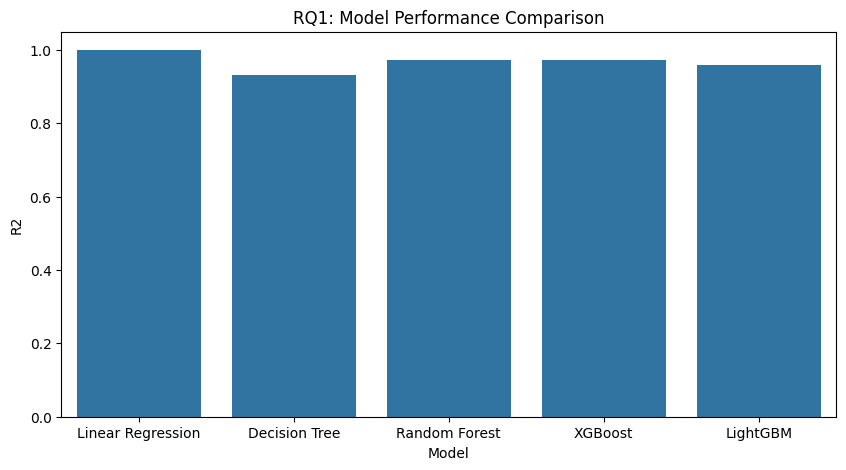

In [6]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2'
)

plt.title(
    'RQ1: Model Performance Comparison'
)

plt.show()

In [7]:
best_model = XGBRegressor(
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

explainer = shap.Explainer(
    best_model
)

shap_values = explainer(
    X_test
)

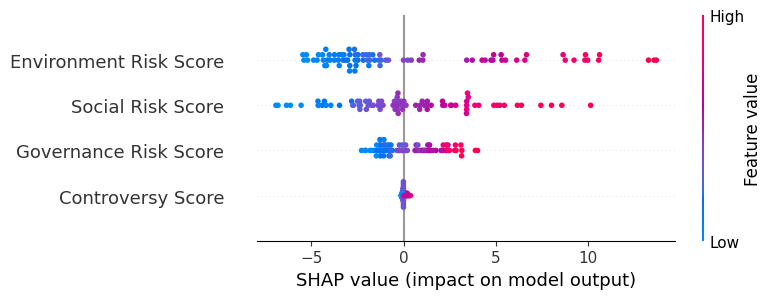

In [8]:
shap.summary_plot(
    shap_values,
    X_test
)

In [9]:
missing_results = []

for missing_pct in [5,10,20,30]:

    X_missing = X.copy()

    mask = np.random.rand(
        *X_missing.shape
    ) < missing_pct/100

    X_missing = X_missing.mask(mask)

    X_missing.fillna(
        X_missing.mean(),
        inplace=True
    )

    Xtr,Xte,Ytr,Yte = train_test_split(
        X_missing,
        y,
        test_size=0.2,
        random_state=42
    )

    model = XGBRegressor(
        random_state=42
    )

    model.fit(Xtr,Ytr)

    pred = model.predict(Xte)

    r2 = r2_score(
        Yte,
        pred
    )

    missing_results.append([
        missing_pct,
        r2
    ])

missing_df = pd.DataFrame(
    missing_results,
    columns=[
        'Missing %',
        'R2'
    ]
)

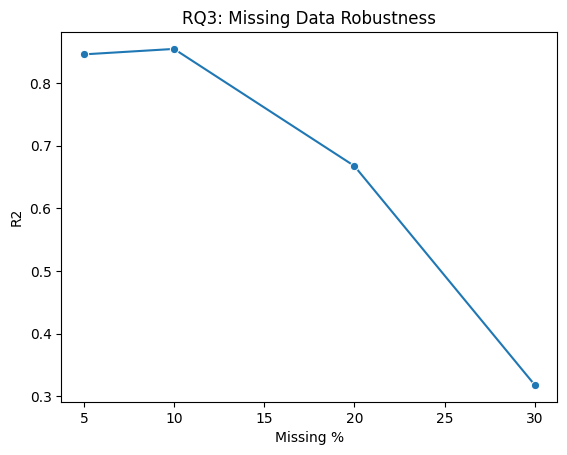

In [10]:
sns.lineplot(
    data=missing_df,
    x='Missing %',
    y='R2',
    marker='o'
)

plt.title(
    'RQ3: Missing Data Robustness'
)

plt.show()

In [11]:
noise_results = []

for noise in [5,10,15,20]:

    X_noise = X.copy()

    X_noise += np.random.normal(
        0,
        noise,
        X_noise.shape
    )

    Xtr,Xte,Ytr,Yte = train_test_split(
        X_noise,
        y,
        test_size=0.2,
        random_state=42
    )

    model = XGBRegressor(
        random_state=42
    )

    model.fit(Xtr,Ytr)

    pred = model.predict(Xte)

    rmse = np.sqrt(
        mean_squared_error(
            Yte,
            pred
        )
    )

    noise_results.append([
        noise,
        rmse
    ])

noise_df = pd.DataFrame(
    noise_results,
    columns=[
        'Noise',
        'RMSE'
    ]
)

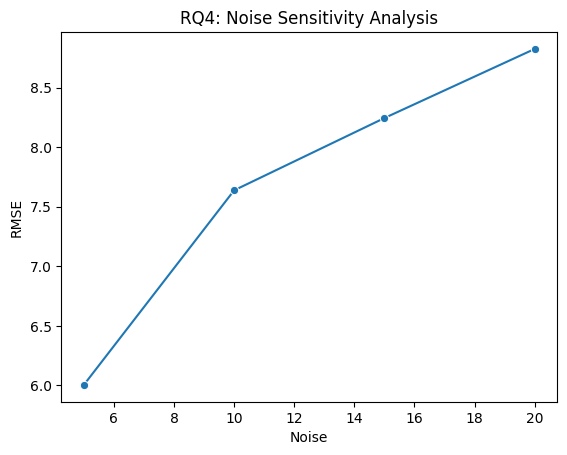

In [12]:
sns.lineplot(
    data=noise_df,
    x='Noise',
    y='RMSE',
    marker='o'
)

plt.title(
    'RQ4: Noise Sensitivity Analysis'
)

plt.show()

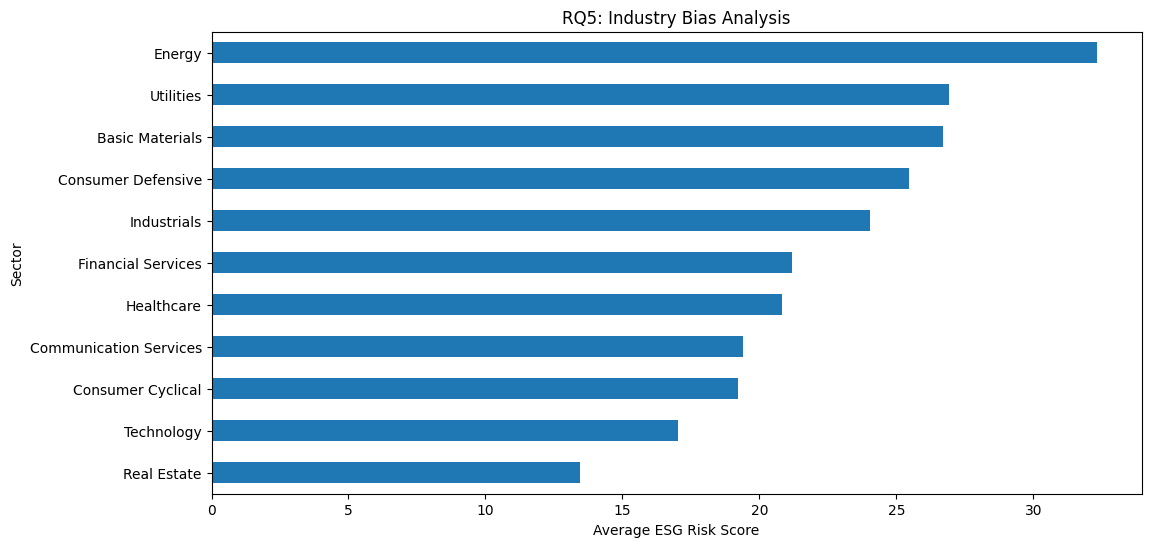

In [13]:
sector_scores = df.groupby(
    'Sector'
)['Total ESG Risk score'].mean()

sector_scores = sector_scores.sort_values()

plt.figure(figsize=(12,6))

sector_scores.plot(
    kind='barh'
)

plt.title(
    'RQ5: Industry Bias Analysis'
)

plt.xlabel(
    'Average ESG Risk Score'
)

plt.show()